## Adam Optimizer

In this Notebook we will try to implement a simple **2nd Degree Polynomial Regression Model** with momentum, RMS prop and adam. <br>We will follow this model :- 
<br><br><img src="../data/model.png" alt="Description" width="800" height="500">


In [26]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Loading and viewing the data

In [27]:
df = pd.read_csv("../data/dummy.csv")
df.head()

,Brightness Level,Power Consumed
0,1.000000,7.028105
1,1.045226,4.256111
2,1.090452,5.371115
3,1.135678,7.855312
4,1.180905,7.070575


plotting scatterplot with our data

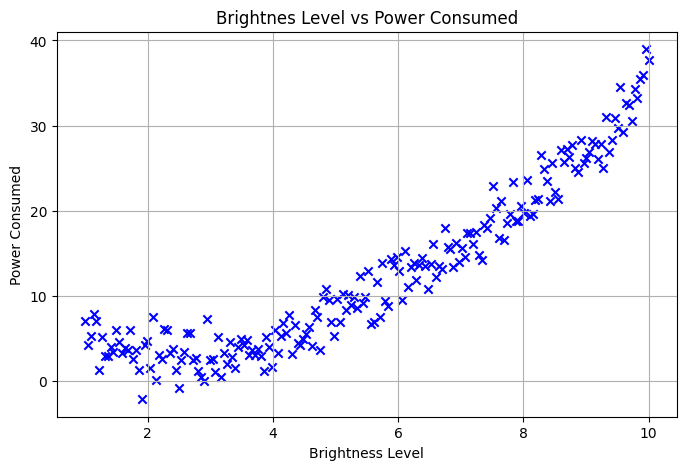

In [28]:
plt.figure(figsize=(8,5))
plt.scatter(df["Brightness Level"], df["Power Consumed"], color="blue", marker = "x")
plt.title("Brightnes Level vs Power Consumed")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.grid(True)

In [29]:
x_train, x_test, y_train, y_test = train_test_split(df["Brightness Level"].to_numpy(dtype=float), df["Power Consumed"].to_numpy(dtype=float), test_size=0.2, random_state=42)
print(f"Shape of training inp features : {x_train.shape}")
print(f"Shape of testing inp features : {x_test.shape}")

Shape of training inp features : (160,)
Shape of testing inp features : (40,)


In [30]:
parameters = np.array([0.015,0.5,0.4])

lets visualize the model with current parameters

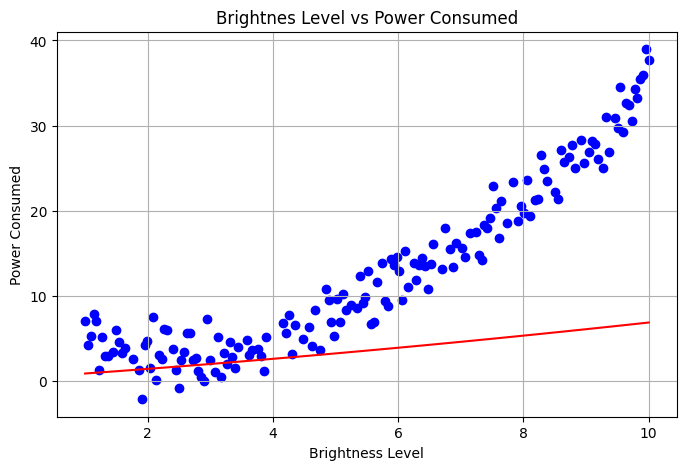

In [31]:
plt.figure(figsize=(8,5))
plt.scatter(x_train, y_train, color="blue")
plt.plot(np.linspace(1,10,100), parameters[0] * np.linspace(1,10,100) **2 + parameters[1]*np.linspace(1,10,100) + parameters[2], color = "red")
plt.title("Brightnes Level vs Power Consumed")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.grid(True)

## Let's Review Yesterday's Functions

In [32]:
def predict(x:np.array, params:np.array):
    y_pred = None
    y_pred = params[0] * x **2 + params[1] * x + params[2]
    return y_pred

In [33]:
def compute_cost(x:np.array, y:np.array, params:np.array):
    cost = 0
    cost = np.average((y - predict(x,params)) ** 2)
    return cost

In [34]:
def compute_gradients(x:np.array, y:np.array, params:np.array):
    gradients = np.array([0,0,0])
    gradients[0] = -2 * np.average((y - predict(x,params)) * x **2)
    gradients[1] = -2 * np.average((y - predict(x,params)) * x)
    gradients[2] = -2 * np.average((y - predict(x,params)))
    return gradients


In [35]:
def gradient_descent(x:np.array, y:np.array, params:np.array, epoch = 1000, alpha = 0.0001):
    params_ = params.copy()
    for i in range(epoch):
        if i % 100 == 0:
            print(f"cost = {compute_cost(x,y,params)}")
        params_ -= alpha * compute_gradients(x,y,params)
    return params_


### Looking at some more OPtimization Algorithms

## Gradient Descent with momentum
Here, insted of using gradient at each point to adjust the parameters we will use ***Exponential Moving average of gradients***
<br>
$m_t = \beta . m_{t-1} + (1 - \beta).g_t$ <br>

updating the parameters :- <br>
$w_1 = w_1 - \alpha.m_t$ <br>
$w_2 = w_2 - \alpha.m_t$<br>
$b = b - \alpha.m_t$


Lets write a function for gradient Descent with momenntum<br>
**Structure :**<br>
`Function Parameters : inp_feature_x (numpy array),output_labels_y (numpy array) ,params (numpy array)`<br>
`Default Parameters: beta = 0.9, alpha = 0.0001, epoch = 1000`
`Function Return : gradients (numpy array)`

In [93]:
def gradient_descent_momentum(x:np.array, y:np.array,params:np.array,epoch = 1000,alpha = 0.001, beta = 0.9):
    momentum = np.zeros_like(parameters)
    params_ = params.copy()
    #Begin Your Code Here
    for i in range(epoch):
        grad = compute_gradients(x,y,params_)
        momentum = beta * momentum + (1 - beta) * grad
        params_ -= alpha * momentum
        if i % 50 == 0:
            print(f"cost = {compute_cost(x,y,params_)}")
    #End Your Code Here
    return params_

In [94]:
new_params_mom = gradient_descent_momentum(x_train, y_train, parameters,epoch=500)
new_params_mom

cost = 49.455726869982975
cost = 6.698631796754052
cost = 6.315829488024929
cost = 6.1928615570970775
cost = 6.113114745700026
cost = 6.045348277074524
cost = 5.99414536597777
cost = 5.973562024676223
cost = 5.967954482768768
cost = 5.967927050449683


array([0.323, 0.072, 0.374])

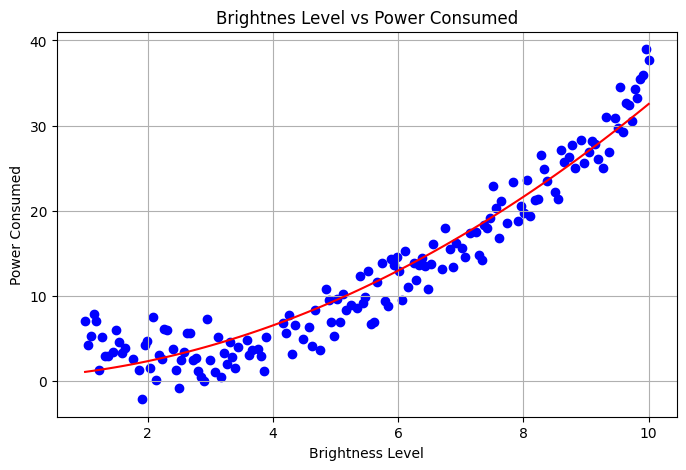

In [76]:
plt.figure(figsize=(8,5))
plt.scatter(x_train, y_train, color="blue")
plt.plot(np.linspace(1,10,100), new_params_mom[0] * np.linspace(1,10,100) **2 + new_params_mom[1]*np.linspace(1,10,100) + new_params_mom[2], color = "red")
plt.title("Brightnes Level vs Power Consumed")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.grid(True)

as we had started with all momenntum  to zero. So innitial steps are very small for that reason we need  to correct bias in initial steps. <br>
$m_t = \frac{m_t}{(1 - \beta ^ t)} $

In [91]:
def gradient_descent_momentum_corrected(x:np.array, y:np.array,params:np.array,epoch = 1000,alpha = 0.001, beta = 0.9):
    momentum = np.zeros_like(parameters)
    params_ = params.copy()
    #Begin Your Code Here
    for i in range(epoch):
        t = i + 1
        grad = compute_gradients(x,y,params_)
        momentum = beta * momentum + (1 - beta) * grad
        momentum_c = momentum / (1 - beta**t)
        params_ -= alpha * momentum_c
        if i % 50 == 0:
            print(f"cost = {compute_cost(x,y,params_)}")
    #End Your Code Here
    return params_

In [92]:
new_params_momc = gradient_descent_momentum_corrected(x_train,  y_train, parameters,epoch=500)

cost = 1986.3946309871287
cost = 7.764572072875856
cost = 6.266732887580721
cost = 6.151737101143778
cost = 6.077576946441573
cost = 6.016674690493642
cost = 5.984860123420412
cost = 5.971266775079138
cost = 5.969199098295519
cost = 5.9690798291388685


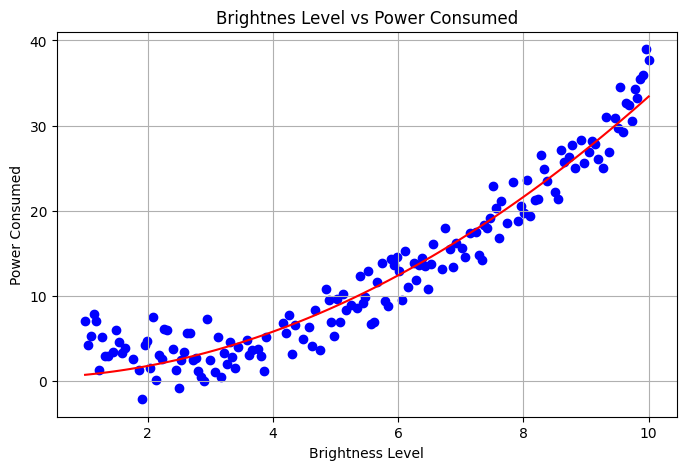

In [95]:
plt.figure(figsize=(8,5))
plt.scatter(x_train, y_train, color="blue")
plt.plot(np.linspace(1,10,100), new_params_momc[0] * np.linspace(1,10,100) **2 + new_params_momc[1]*np.linspace(1,10,100) + new_params_momc[2], color = "red")
plt.title("Brightnes Level vs Power Consumed")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.grid(True)

## Gradient Descent with RMS Prop
Here, insted of using static learning rate we adjust the learning rate with the help of ***Exponential Moving average of squared gradients***
<br>
$v_t = \beta . v_{t-1} + (1 - \beta).g_t^2$ <br>

updating the parameters :- <br>
$$\begin{aligned}
w_1 &= w_1 - \alpha \cdot \frac{g_{w_1}}{\sqrt{v_{w_1}} + \epsilon} \\
w_2 &= w_2 - \alpha \cdot \frac{g_{w_2}}{\sqrt{v_{w_2}} + \epsilon} \\
b &= b - \alpha \cdot \frac{g_b}{\sqrt{v_b} + \epsilon}
\end{aligned}$$


Lets write a function for gradient Descent with RMS Prop<br>
**Structure :**<br>
`Function Parameters : inp_feature_x (numpy array),output_labels_y (numpy array) ,params (numpy array)`<br>
`Default Parameters: beta = 0.999, alpha = 0.0001, epoch = 1000` <br>
`Function Return : parameters (numpy array)`

In [110]:
def gradient_descent_RMS_corrected(x:np.array, y:np.array,params:np.array,epoch = 1000,alpha = 0.001, beta = 0.999, epsilon = 1e-8):
    v = np.zeros_like(parameters)
    params_ = params.copy()
    #Begin Your Code Here
    for i in range(epoch):
        t = i + 1
        grad = compute_gradients(x,y,params_)
        v = beta * v + (1 - beta) * grad ** 2
        v_c = v / (1 - beta**t)
        params_ -= (alpha/np.sqrt(v_c)) * grad
        if i % 50 == 0:
            print(f"cost = {compute_cost(x,y,params_)}")
    #End Your Code Here
    return params_

In [111]:
new_params_RMSc = gradient_descent_RMS_corrected(x_train,  y_train, parameters,beta=0.9)

cost = 154.23052464609304
cost = 97.25118678114552
cost = 55.14544646113969
cost = 26.87352423760034
cost = 11.79384406382448
cost = 7.776265491486294
cost = 7.488842679187238
cost = 7.288279566849627
cost = 7.112756069276159
cost = 6.944287160285943
cost = 6.790886884006376
cost = 6.652027620694082
cost = 6.519380962926709
cost = 6.399625831094046
cost = 6.2910030104619015
cost = 6.198965312418176
cost = 6.112252235296903
cost = 6.035311245174928
cost = 5.972570066160499
cost = 5.920351259688407


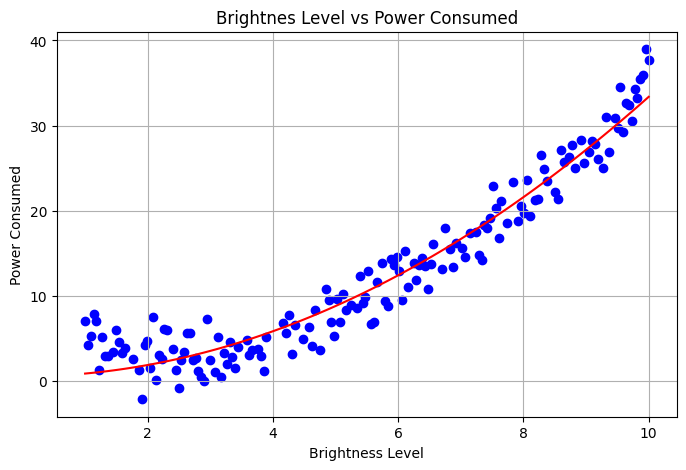

In [112]:
plt.figure(figsize=(8,5))
plt.scatter(x_train, y_train, color="blue")
plt.plot(np.linspace(1,10,100), new_params_RMSc[0] * np.linspace(1,10,100) **2 + new_params_RMSc[1]*np.linspace(1,10,100) + new_params_RMSc[2], color = "red")
plt.title("Brightnes Level vs Power Consumed")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.grid(True)

## Adam Optimizer
Here, insted of using gradient at each point to adjust the parameters we will use ***Momemtum of gradients*** and insted of using a static learning rate we will us ***RMS Propagation*** to adjust learning rate.
<br>
$$
\begin{aligned}
m_t &= \beta_1 m_{t-1} + (1 - \beta_1) g_t \\
v_t &= \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 \\
\hat{m}_t &= \frac{m_t}{1 - \beta_1^t} \quad \text{(bias-corrected first moment)} \\
\hat{v}_t &= \frac{v_t}{1 - \beta_2^t} \quad \text{(bias-corrected second moment)} \\
\theta_t &= \theta_{t-1} - \alpha \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
\end{aligned}
$$


In [122]:
def adam_optimizer(x:np.array, y:np.array,params:np.array,epoch = 1000,alpha = 0.001, beta1 = 0.99,beta2 = 0.999, epsilon = 1e-8):
    v = np.zeros_like(parameters)
    m = np.zeros_like(parameters)
    params_ = params.copy()
    #Begin Your Code Here
    for i in range(epoch):
        t = i+1
        grad = compute_gradients(x,y,params_)
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * grad**2
        m_c = m / (1 - beta1 ** t)
        v_c = v / (1 - beta2 ** t)
        params_ -= (alpha / np.sqrt(v_c + epsilon)) * m_c
        if i % 50 == 0:
            print(f"cost = {compute_cost(x,y,params_)}")
    #End Your Code Here
    return params_

In [135]:
new_params_adam = adam_optimizer(x_train,  y_train, parameters,beta2=0.999, alpha=0.6, epoch=500)

cost = 431.68846280069056
cost = 64.34789742566294
cost = 24.11360754376923
cost = 7.462026462338073
cost = 5.217053100818035
cost = 6.366649695708631
cost = 9.822193452570648
cost = 7.491212268573856
cost = 5.144841235873481
cost = 5.266663763509262


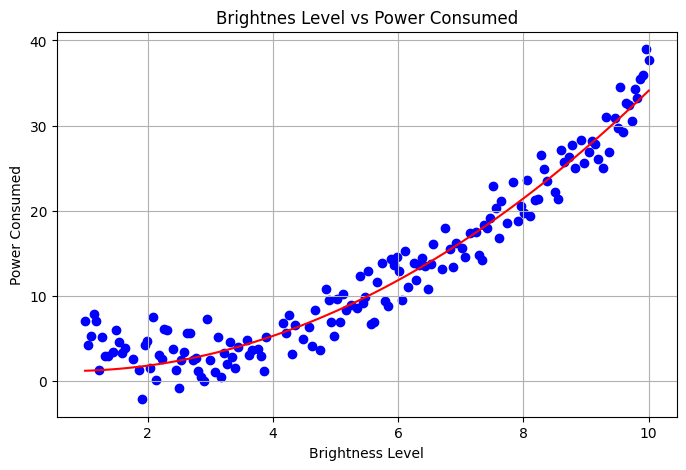

In [129]:
plt.figure(figsize=(8,5))
plt.scatter(x_train, y_train, color="blue")
plt.plot(np.linspace(1,10,100), new_params_adam[0] * np.linspace(1,10,100) **2 + new_params_adam[1]*np.linspace(1,10,100) + new_params_adam[2], color = "red")
plt.title("Brightnes Level vs Power Consumed")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.grid(True)